# Alpamayo 2 Super VQA

Run this notebook from the repository root with the `Alpamayo 2 Super` kernel. Set `ALPAMAYO2_SUPER_MODEL_ID` to a Hugging Face model id or local release checkpoint before starting the kernel. VQA and grounding select their validated six-camera/four-frame input profiles independently.

In [17]:
import json
import os
from pathlib import Path

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import matplotlib.pyplot as plt
import torch
from IPython.display import display

from alpamayo2_super import helper
from alpamayo2_super.common.constants import PUBLIC_MODEL_ID
from alpamayo2_super.inference_smoke import resolve_project_path, validate_model_id
from alpamayo2_super.input_profiles import select_task_input
from alpamayo2_super.load_physical_aiavdataset import load_physical_aiavdataset
from alpamayo2_super.models.alpamayo2_super import Alpamayo2Super
from alpamayo2_super.text_tasks import (
    DEFAULT_GROUNDING_QUESTION,
    generate_text,
    prepare_vqa_inputs,
)
from alpamayo2_super.visualization import plot_grounding_result, plot_vqa_result

In [ ]:
cwd = Path.cwd()
if (cwd / "examples").exists():
    project_root = cwd
elif (cwd.parent / "examples").exists():
    project_root = cwd.parent
else:
    project_root = cwd

MODEL_ID = os.environ.get("ALPAMAYO2_SUPER_MODEL_ID", PUBLIC_MODEL_ID)
MANIFEST = resolve_project_path(
    os.environ.get("ALPAMAYO2_SUPER_VALIDATION_MANIFEST", "examples/validation_samples.json"),
    project_root,
)
SAMPLE_INDEX = int(os.environ.get("ALPAMAYO2_SUPER_SAMPLE_INDEX", "0"))
QUESTION = os.environ.get(
    "ALPAMAYO2_SUPER_VQA_QUESTION",
    "Is 'Slow down' the right driving decision?",
)
GROUNDING_QUESTION = os.environ.get(
    "ALPAMAYO2_SUPER_GROUNDING_QUESTION",
    DEFAULT_GROUNDING_QUESTION,
)
MAX_NEW_TOKENS = int(os.environ.get("ALPAMAYO2_SUPER_VQA_MAX_NEW_TOKENS", "1024"))
GROUNDING_MAX_NEW_TOKENS = int(
    os.environ.get("ALPAMAYO2_SUPER_GROUNDING_MAX_NEW_TOKENS", str(MAX_NEW_TOKENS))
)
TEMPERATURE = float(os.environ.get("ALPAMAYO2_SUPER_VQA_TEMPERATURE", "0.1"))
TOP_P = float(os.environ.get("ALPAMAYO2_SUPER_VQA_TOP_P", "1.0"))
SEED = int(os.environ.get("ALPAMAYO2_SUPER_SEED", "42"))
OUTPUT_DIR = resolve_project_path(
    os.environ.get("ALPAMAYO2_SUPER_OUTPUT_DIR", "outputs"), project_root
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sample = json.loads(MANIFEST.read_text(encoding="utf-8"))["samples"][SAMPLE_INDEX]
clip_id = os.environ.get("ALPAMAYO2_SUPER_CLIP_ID", sample["clip_id"])
t0_us = int(os.environ.get("ALPAMAYO2_SUPER_T0_US", str(sample["t0_us"])))
validate_model_id(MODEL_ID)
if not torch.cuda.is_available():
    raise RuntimeError("Alpamayo 2 Super VQA requires a CUDA GPU.")

print("model:", MODEL_ID)
print("sample:", SAMPLE_INDEX, clip_id, t0_us)
print("vqa question:", QUESTION)
print("grounding question:", GROUNDING_QUESTION)

model: nvidia/Alpamayo2-Super
sample: 0 030c760c-ae38-49aa-9ad8-f5650a545d26 5100000
vqa question: Is 'Slow down' the right driving decision?
grounding question: Find the white lead vehicle directly ahead and return its bounding box in JSON.


In [46]:
source_data = load_physical_aiavdataset(
    clip_id,
    t0_us=t0_us,
)
vqa_data = select_task_input(source_data, "vqa")
grounding_data = select_task_input(source_data, "grounding")
print("vqa_camera_indices:", vqa_data["camera_indices"].tolist())
print("grounding_camera_indices:", grounding_data["camera_indices"].tolist())

vqa_camera_indices: [0, 1, 2, 3, 4, 5]
grounding_camera_indices: [0, 1, 2, 3, 5, 6]


In [20]:
model = Alpamayo2Super.from_pretrained(MODEL_ID, dtype=torch.bfloat16, device_map="cuda:0")

Loading checkpoint shards:   0%|          | 0/15 [00:00<?, ?it/s]

In [47]:
vqa_inputs = prepare_vqa_inputs(
    data=vqa_data,
    model_config=model.config,
    tokenizer=model.tokenizer,
    question=QUESTION,
)
vqa_inputs = helper.to_device(vqa_inputs, "cuda")

torch.cuda.manual_seed_all(SEED)
with torch.autocast("cuda", dtype=torch.bfloat16):
    vqa_result = generate_text(
        model,
        vqa_inputs,
        top_p=TOP_P,
        temperature=TEMPERATURE,
        max_new_tokens=MAX_NEW_TOKENS,
    )

answer = vqa_result["answer"][0]
print("Answer:\n", answer)

Answer:
 Slow down


In [48]:
vqa_inputs = prepare_vqa_inputs(
    data=vqa_data,
    model_config=model.config,
    tokenizer=model.tokenizer,
    question=QUESTION,
)
vqa_inputs = helper.to_device(vqa_inputs, "cuda")

torch.cuda.manual_seed_all(SEED)
with torch.autocast("cuda", dtype=torch.bfloat16):
    vqa_result = generate_text(
        model,
        vqa_inputs,
        top_p=TOP_P,
        temperature=TEMPERATURE,
        max_new_tokens=MAX_NEW_TOKENS,
    )

answer = vqa_result["answer"][0]
print("Answer:\n", answer)
# Inspect the first generated token probability for Yes/No on the VQA prompt
gen_model = getattr(model, "vlm", model)

gen_out = gen_model.generate(
    input_ids=vqa_inputs["tokenized_data"]["input_ids"],
    attention_mask=vqa_inputs["tokenized_data"]["attention_mask"],
    pixel_values=vqa_inputs["tokenized_data"]["pixel_values"],
    image_grid_thw=vqa_inputs["tokenized_data"]["image_grid_thw"],
    max_new_tokens=1,
    do_sample=False,
    output_scores=True,
    return_dict_in_generate=True,
)

scores = gen_out.scores[0]  # [batch, vocab] for the first new token
probs = torch.softmax(scores[0], dim=-1)

def text_prob(text):
    ids = model.tokenizer.encode(text, add_special_tokens=False)
    if not ids:
        return 0.0
    return float(probs[ids].sum().item())

yes_variants = ["Yes", "yes", " YES", " yes", "YES"]
no_variants = ["No", "no", " NO", " no", "NO"]

yes_entries = [(v, text_prob(v)) for v in yes_variants]
no_entries = [(v, text_prob(v)) for v in no_variants]

yes_best = max(yes_entries, key=lambda x: x[1])
no_best = max(no_entries, key=lambda x: x[1])

# print("Yes candidates:", yes_entries)
# print("No candidates:", no_entries)
print("Best Yes token probability:", yes_best)
print("Best No token probability:", no_best)

topk = torch.topk(probs, 20)
top_tokens = model.tokenizer.convert_ids_to_tokens(topk.indices.tolist())
top_probs = topk.values.tolist()
# print("Top first-token logits:", list(zip(top_tokens, top_probs)))

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Answer:
 Slow down
Best Yes token probability: ('Yes', 0.2934335470199585)
Best No token probability: ('No', 0.017622055485844612)


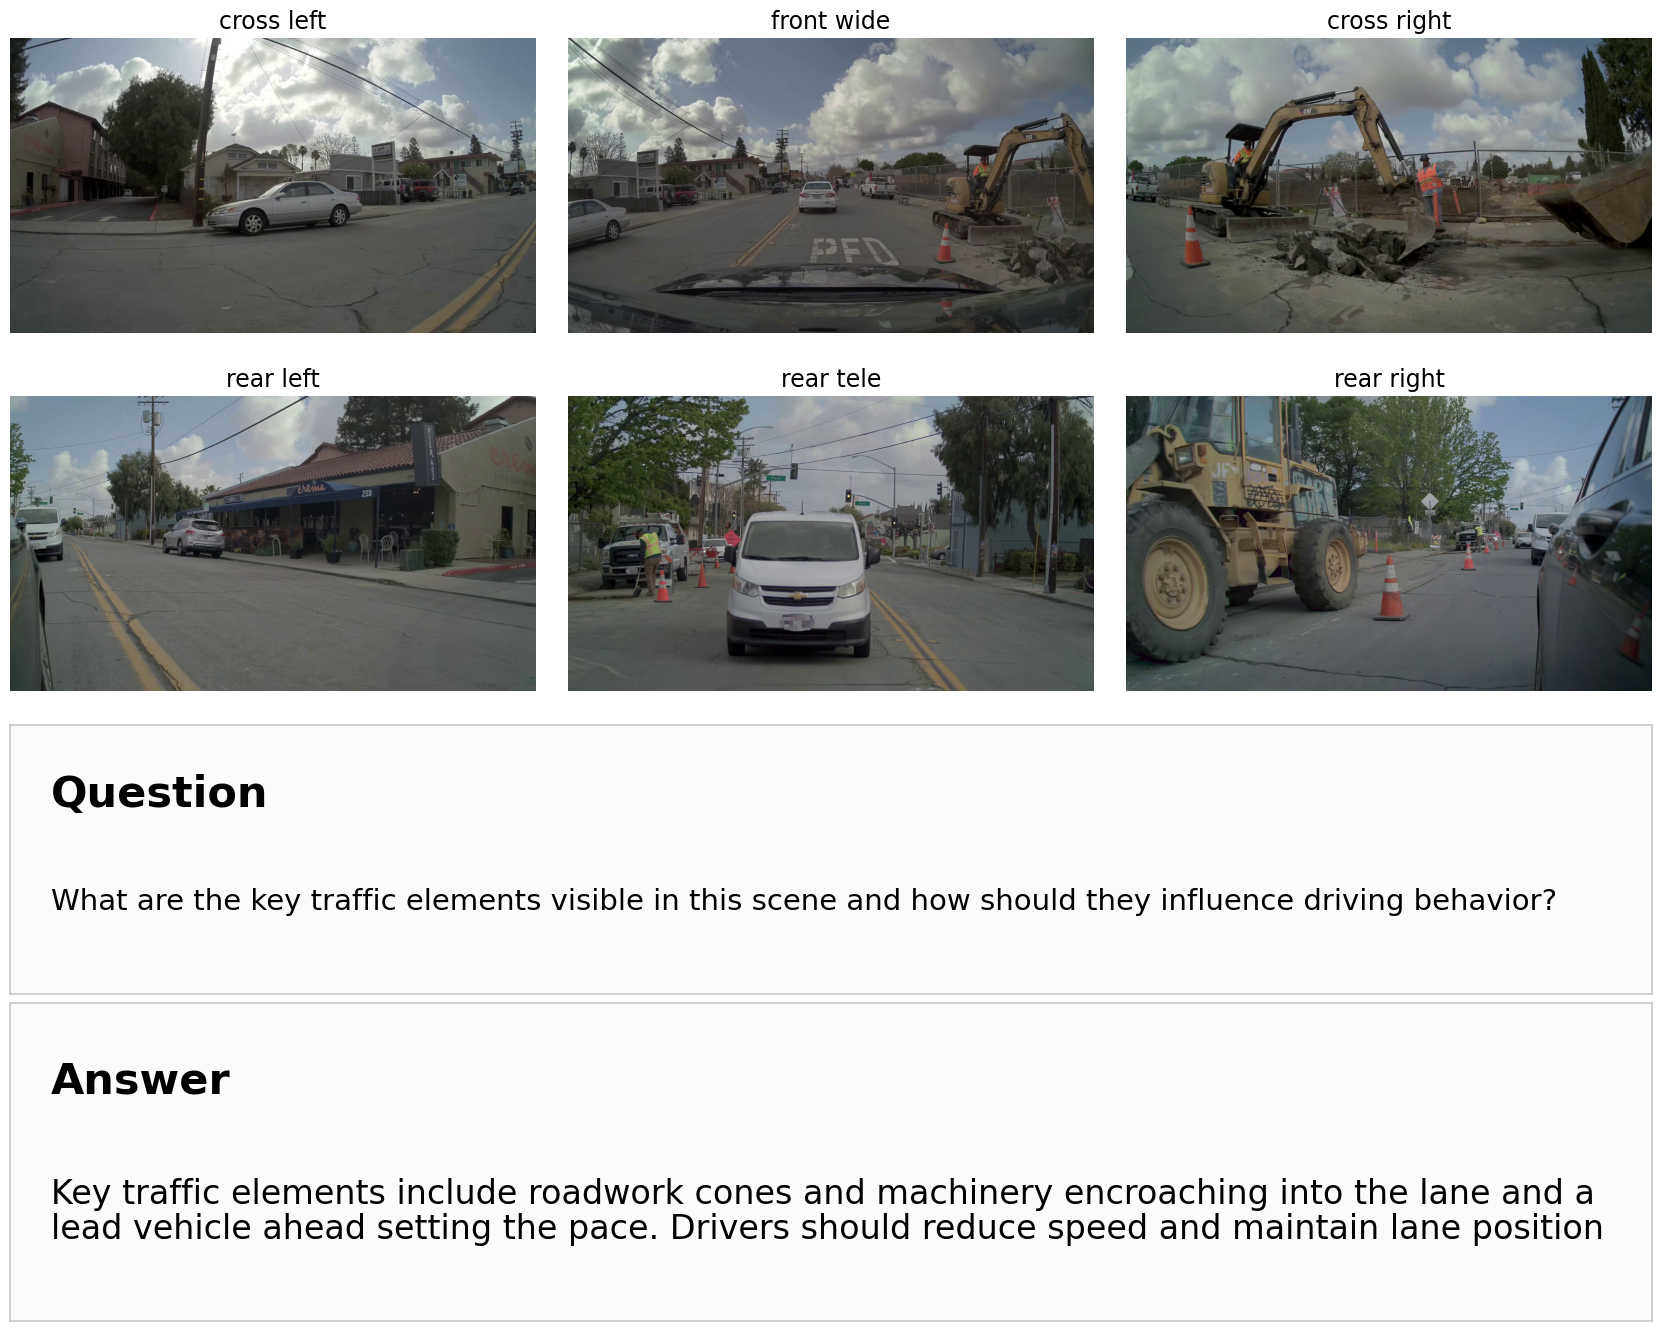

saved_png: /mnt/efs/users/rod/repos/alpamayo2/outputs/vqa_sample0_030c760c-ae38-49aa-9ad8-f5650a545d26_5100000.png
saved_json: /mnt/efs/users/rod/repos/alpamayo2/outputs/vqa_sample0_030c760c-ae38-49aa-9ad8-f5650a545d26_5100000.json


In [14]:
artifact_stem = f"vqa_sample{SAMPLE_INDEX}_{clip_id}_{t0_us}"
figure_path = OUTPUT_DIR / f"{artifact_stem}.png"
json_path = OUTPUT_DIR / f"{artifact_stem}.json"
fig, figure_metadata = plot_vqa_result(
    data=vqa_data,
    question=QUESTION,
    answer=answer,
    output_path=figure_path,
    model_id=MODEL_ID,
    seed=SEED,
)
display(fig)
plt.close(fig)
payload = {
    "task": "vqa",
    "model_id": MODEL_ID,
    "clip_id": clip_id,
    "t0_us": t0_us,
    "seed": SEED,
    "question": QUESTION,
    "top_p": TOP_P,
    "temperature": TEMPERATURE,
    "max_new_tokens": MAX_NEW_TOKENS,
    "answer": answer,
    "raw_output": vqa_result["raw_outputs"][0],
    "figure_path": str(figure_path),
    "figure_metadata": figure_metadata,
}
json_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
print("saved_png:", figure_path)
print("saved_json:", json_path)

In [15]:
grounding_inputs = prepare_vqa_inputs(
    data=grounding_data,
    model_config=model.config,
    tokenizer=model.tokenizer,
    question=GROUNDING_QUESTION,
)
grounding_inputs = helper.to_device(grounding_inputs, "cuda")

torch.cuda.manual_seed_all(SEED)
with torch.autocast("cuda", dtype=torch.bfloat16):
    grounding_result = generate_text(
        model,
        grounding_inputs,
        top_p=TOP_P,
        temperature=TEMPERATURE,
        max_new_tokens=GROUNDING_MAX_NEW_TOKENS,
    )

print(grounding_result)
grounding_answer = grounding_result["answer"][0]
grounding_box = grounding_result.get("box", [""])[0]
print("Grounding answer:\n", grounding_answer)
if grounding_box:
    print("Box grounding:\n", grounding_box)

{'raw_outputs': ['[{"bbox_2d": [429, 483, 515, 597], "label": "Car"}]<|im_end|>'], 'cot': ['[{"bbox_2d": [429, 483, 515, 597], "label": "Car"}]'], 'meta_action': [''], 'answer': ['[{"bbox_2d": [429, 483, 515, 597], "label": "Car"}]'], 'box': ['[{"bbox_2d": [429, 483, 515, 597], "label": "Car"}]'], 'cot_auto_labeling': ['']}
Grounding answer:
 [{"bbox_2d": [429, 483, 515, 597], "label": "Car"}]
Box grounding:
 [{"bbox_2d": [429, 483, 515, 597], "label": "Car"}]


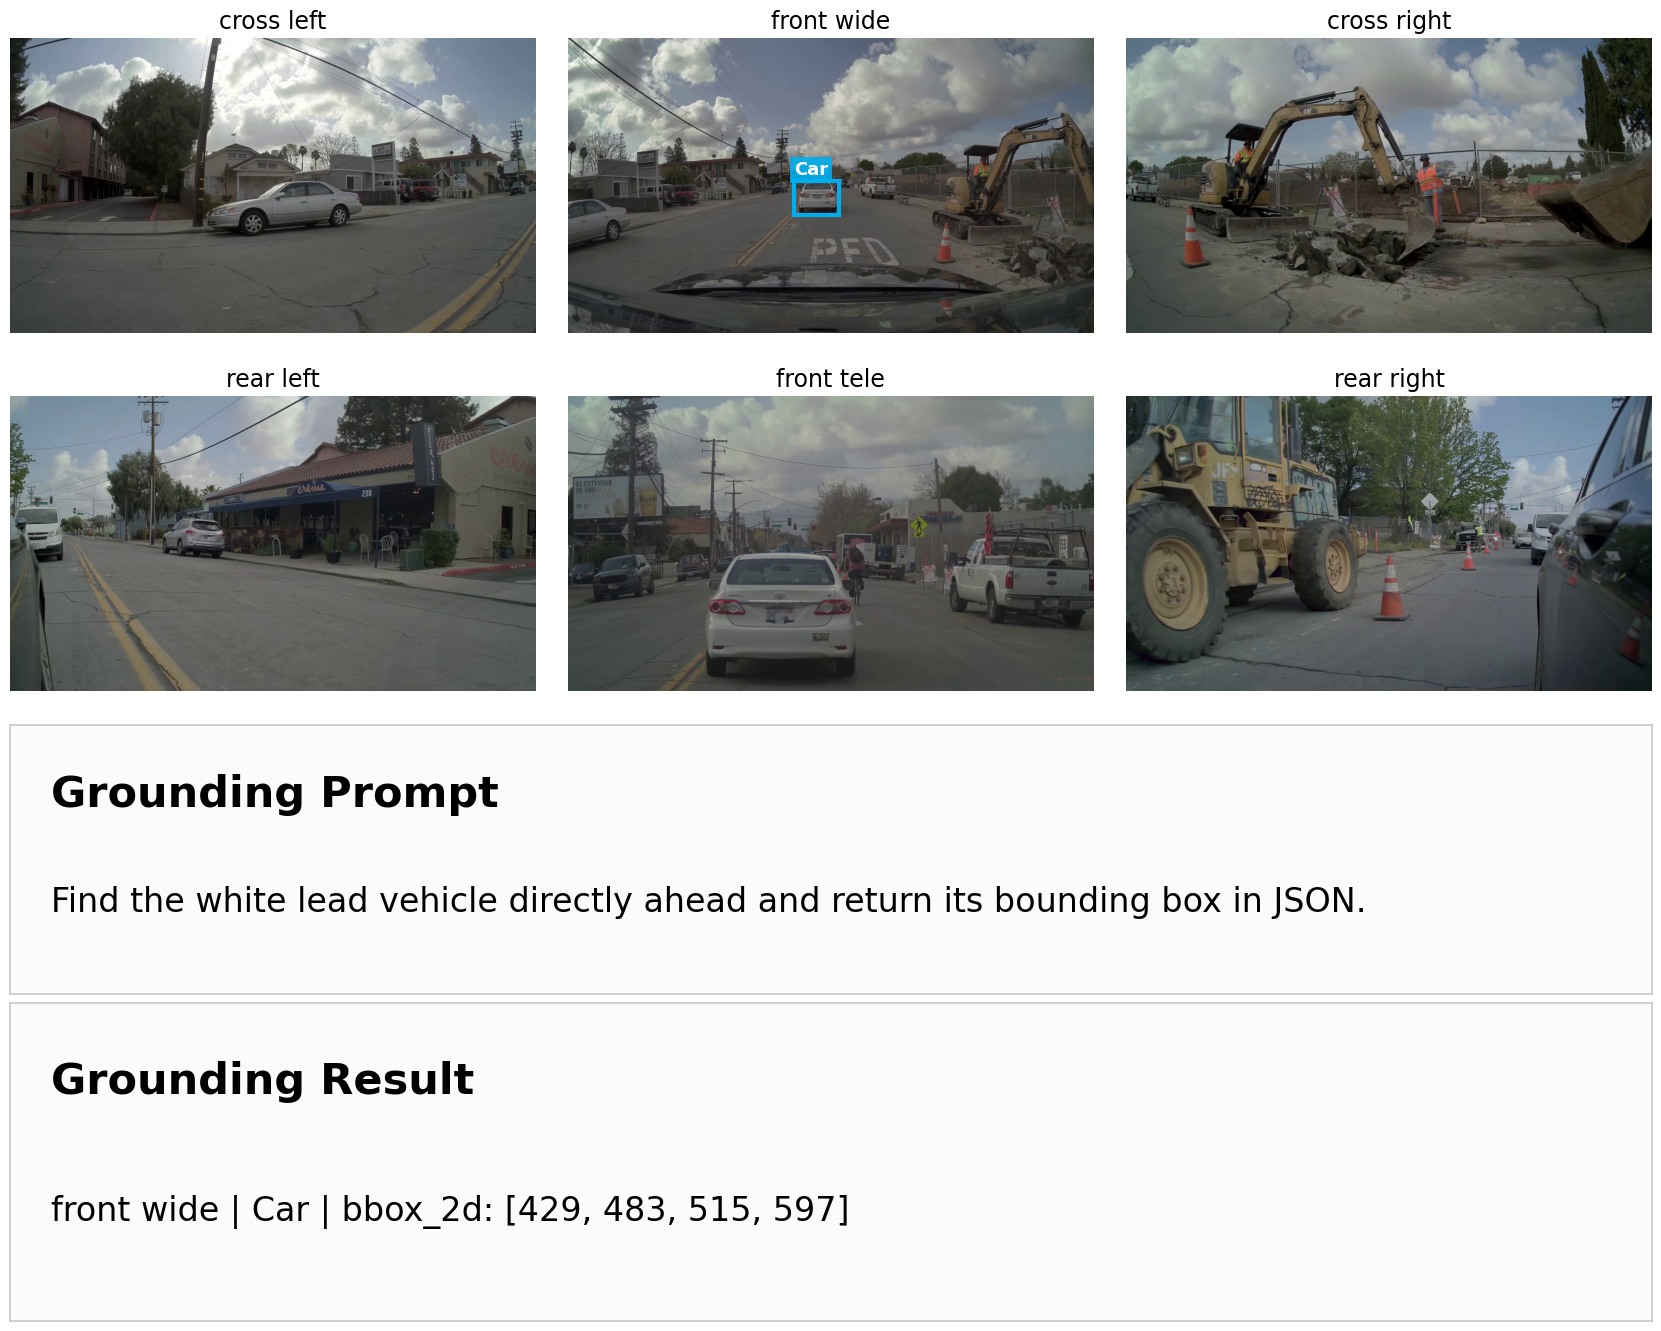

saved_png: /mnt/efs/users/rod/repos/alpamayo2/outputs/grounding_sample0_030c760c-ae38-49aa-9ad8-f5650a545d26_5100000.png
saved_json: /mnt/efs/users/rod/repos/alpamayo2/outputs/grounding_sample0_030c760c-ae38-49aa-9ad8-f5650a545d26_5100000.json


In [16]:
artifact_stem = f"grounding_sample{SAMPLE_INDEX}_{clip_id}_{t0_us}"
grounding_figure_path = OUTPUT_DIR / f"{artifact_stem}.png"
grounding_json_path = OUTPUT_DIR / f"{artifact_stem}.json"
fig, grounding_figure_metadata = plot_grounding_result(
    data=grounding_data,
    question=GROUNDING_QUESTION,
    answer=grounding_answer,
    grounding_text=grounding_box or grounding_answer,
    output_path=grounding_figure_path,
    model_id=MODEL_ID,
    seed=SEED,
)
display(fig)
plt.close(fig)
payload = {
    "task": "grounding",
    "model_id": MODEL_ID,
    "clip_id": clip_id,
    "t0_us": t0_us,
    "seed": SEED,
    "question": GROUNDING_QUESTION,
    "top_p": TOP_P,
    "temperature": TEMPERATURE,
    "max_new_tokens": GROUNDING_MAX_NEW_TOKENS,
    "answer": grounding_answer,
    "box": grounding_box,
    "raw_output": grounding_result["raw_outputs"][0],
    "figure_path": str(grounding_figure_path),
    "figure_metadata": grounding_figure_metadata,
}
grounding_json_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
print("saved_png:", grounding_figure_path)
print("saved_json:", grounding_json_path)